# Week 3: Temporal difference and intro to deep RL

This notebook will contain
- Discussions on temporal-difference learning
- Moving from tabular methods to neural network methods (Deep Reinforcement Learning)

## From Monte Carlo to temporal-difference learning

Monte Carlo methods estimate value functions from complete returns. For an episodic trajectory, the update target is the observed return

$$
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2R_{t+3}
+\cdots.
$$

This has an important limitation: the agent must normally wait until the episode terminates before it can update its value estimates. In long or continuing tasks, this may be inefficient.

**Temporal-difference learning** combines ideas from Monte Carlo methods and dynamic programming. Like Monte Carlo, TD learns directly from sampled experience and does not require the transition-reward kernel $p(s',r\mid s,a)$. Like dynamic programming, it updates an estimate using another value estimate. This is called **bootstrapping**.

The simplest TD prediction update is TD(0):

$$
V(S_t)
\leftarrow
V(S_t)
+
\alpha
\left[
R_{t+1}
+
\gamma V(S_{t+1})
-
V(S_t)
\right].
$$

The quantity

$$
\delta_t
=
R_{t+1}
+
\gamma V(S_{t+1})
-
V(S_t)
$$

is called the **temporal-difference error**. It measures the difference between the current estimate and the one-step target.

### Main variants

**TD prediction** estimates $v_\pi$ for a fixed policy using one-step transitions.

**SARSA** is an on-policy control method. It updates the action-value function using the action actually selected by the current policy:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\right].
$$

**Q-learning** is an off-policy control method. It updates toward the value of the greedy next action:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_a Q(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

**Expected SARSA** replaces the sampled next action by its expected value under the policy:

$$
R_{t+1}
+
\gamma
\sum_a
\pi(a\mid S_{t+1})Q(S_{t+1},a).
$$

More general methods include **$n$-step TD**, which uses several rewards before bootstrapping, and **TD($\lambda$)**, which combines information from returns of different lengths.

The main motivation for TD methods is that they can learn after every transition. This often makes them more suitable than Monte Carlo methods for long episodes, continuing tasks, and real-time control problems in robotics, molecular dynamics, and quantum technology.


## From tabular learning to deep reinforcement learning

Monte Carlo and temporal-difference methods are often introduced in a **tabular** setting. Each state or state-action pair has its own stored estimate, such as $V(s)$ or $Q(s,a)$. This works when the state and action spaces are small, but becomes impractical when states are continuous, high-dimensional, or represented by measurements, images, molecular configurations, or quantum states.

Deep reinforcement learning replaces the table by a parametrized function, usually a neural network:

$$
Q(s,a)\approx \hat q(s,a;w),
$$

where $w$ denotes the trainable network parameters. A TD method can then train the network using a target such as

$$
Y_t=R_{t+1}+\gamma\max_{a'}\hat q(S_{t+1},a';w),
$$

and a loss

$$
L(w)=\left[Y_t-\hat q(S_t,A_t;w)\right]^2.
$$

Similarly, a policy may be represented directly as $\pi_\theta(a\mid s)$.

Deep reinforcement learning therefore does not replace Monte Carlo or TD learning. Instead, it combines their sampled targets and update rules with neural-network function approximation, allowing information learned in one state to generalize to similar states.
```



## Quantum control application: robust qubit inversion with discrete control pulses

Consider a two-level quantum system with initial state

$$
|\psi_0\rangle=|0\rangle
$$

and target state

$$
|\psi_{\mathrm{target}}\rangle=|1\rangle.
$$

The objective is to construct a sequence of control pulses that transfers the system from $|0\rangle$ to $|1\rangle$ despite stochastic detuning noise.

At time step $t$, the Hamiltonian is

$$
H_t
=
\frac{\Delta_t}{2}\sigma_z
+
\frac{u_x(A_t)}{2}\sigma_x
+
\frac{u_y(A_t)}{2}\sigma_y,
$$

where $\Delta_t$ is a random detuning sampled independently from

$$
\Delta_t\sim\operatorname{Uniform}
\left[-\Delta_{\max},\Delta_{\max}\right].
$$

The available actions are discrete pulse choices:

$$
A=
\left\{
(0,0),
(\Omega,0),
(-\Omega,0),
(0,\Omega),
(0,-\Omega)
\right\}.
$$

They correspond to no pulse and positive or negative rotations around the $x$ and $y$ axes.

During one time interval $\Delta t$, the state evolves according to

$$
|\psi_{t+1}\rangle
=
\exp(-iH_t\Delta t)|\psi_t\rangle.
$$

The fidelity with the target state is

$$
F_t
=
\left|
\langle 1|\psi_t\rangle
\right|^2.
$$

For tabular reinforcement learning, the continuous quantum state is represented by its Bloch-vector components,

$$
x_t=\langle\psi_t|\sigma_x|\psi_t\rangle,
\qquad
y_t=\langle\psi_t|\sigma_y|\psi_t\rangle,
\qquad
z_t=\langle\psi_t|\sigma_z|\psi_t\rangle,
$$

which are discretized into bins. The RL state is

$$
S_t=
\left(
t,
\operatorname{bin}(x_t),
\operatorname{bin}(y_t),
\operatorname{bin}(z_t)
\right).
$$

Including $t$ in the state makes the finite-horizon control problem Markov.

### Monte Carlo formulation

For Monte Carlo control, all intermediate rewards are zero. At the final time $N$, the reward is

$$
R_N
=
F_N
-
\lambda
\sum_{t=0}^{N-1}
\|u(A_t)\|^2\Delta t.
$$

The agent must therefore complete the full pulse sequence before updating its action values:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\frac{1}{N(S_t,A_t)}
\left[
G_t-Q(S_t,A_t)
\right].
$$

This formulation is appropriate when only the final state can be measured reliably.

### Temporal-difference formulation

For TD learning, we use the shaped reward

$$
R_{t+1}
=
F_{t+1}-F_t
-
\lambda
\|u(A_t)\|^2\Delta t.
$$

For $\gamma=1$, the total return telescopes:

$$
\sum_{t=0}^{N-1}R_{t+1}
=
F_N-F_0
-
\lambda
\sum_{t=0}^{N-1}
\|u(A_t)\|^2\Delta t.
$$

Since $F_0=0$, the terminal and shaped formulations optimize the same final objective. The difference is how credit is assigned during learning.

SARSA uses the on-policy target

$$
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1}),
$$

while Q-learning uses the off-policy target

$$
R_{t+1}
+
\gamma
\max_a Q(S_{t+1},a).
$$

The example therefore allows us to compare:

- complete-return Monte Carlo learning;
- online TD updates;
- on-policy SARSA;
- off-policy Q-learning;
- terminal rewards and shaped rewards;
- fidelity maximization and control-energy penalties.
```


In [1]:
import collections
import numpy as np


# Pauli matrices
I2 = np.eye(2, dtype=complex)

SX = np.array(
    [[0, 1],
     [1, 0]],
    dtype=complex,
)

SY = np.array(
    [[0, -1j],
     [1j, 0]],
    dtype=complex,
)

SZ = np.array(
    [[1, 0],
     [0, -1]],
    dtype=complex,
)

KET0 = np.array([1.0, 0.0], dtype=complex)
KET1 = np.array([0.0, 1.0], dtype=complex)


def apply_pulse(psi, ux, uy, detuning, dt):
    """
    Apply exp(-i H dt) to a qubit state, where

        H = 1/2 (ux sigma_x + uy sigma_y + detuning sigma_z).

    The closed-form Pauli-matrix exponential avoids requiring SciPy.
    """
    field_norm = np.sqrt(
        ux**2 + uy**2 + detuning**2
    )

    if field_norm < 1e-12:
        return psi.copy()

    angle = 0.5 * field_norm * dt

    direction = (
        ux * SX
        + uy * SY
        + detuning * SZ
    ) / field_norm

    unitary = (
        np.cos(angle) * I2
        - 1j * np.sin(angle) * direction
    )

    return unitary @ psi


def bloch_vector(psi):
    """Return the Bloch vector of a normalized qubit state."""
    a, b = psi

    x = 2.0 * np.real(np.conj(a) * b)
    y = 2.0 * np.imag(np.conj(a) * b)
    z = np.abs(a)**2 - np.abs(b)**2

    return np.array([x, y, z], dtype=float)


class QubitPulseEnv:
    """
    Finite-horizon qubit inversion environment.

    Actions:
        0: no pulse
        1: +x pulse
        2: -x pulse
        3: +y pulse
        4: -y pulse
    """

    def __init__(
        self,
        n_steps=12,
        dt=0.25,
        omega=2.0,
        detuning_noise=0.6,
        bins=9,
        control_cost=0.005,
        reward_mode="shaped",
        seed=0,
    ):
        self.n_steps = n_steps
        self.dt = dt
        self.omega = omega
        self.detuning_noise = detuning_noise
        self.bins = bins
        self.control_cost = control_cost
        self.reward_mode = reward_mode

        self.rng = np.random.default_rng(seed)

        self.actions = np.array([
            [0.0, 0.0],
            [ omega, 0.0],
            [-omega, 0.0],
            [0.0,  omega],
            [0.0, -omega],
        ])

        self.n_actions = len(self.actions)

        self.bin_edges = np.linspace(
            -1.0,
            1.0,
            bins + 1,
        )

    def fidelity(self):
        return float(
            np.abs(np.vdot(KET1, self.psi))**2
        )

    def state(self):
        """
        Discretized state:
            (time, x-bin, y-bin, z-bin)
        """
        coordinates = bloch_vector(self.psi)

        indices = tuple(
            np.digitize(
                coordinates,
                self.bin_edges[1:-1],
            )
        )

        return (self.t, *indices)

    def reset(self):
        self.psi = KET0.copy()
        self.t = 0
        self.total_control_cost = 0.0

        return self.state()

    def step(self, action):
        if action < 0 or action >= self.n_actions:
            raise ValueError("Invalid action.")

        fidelity_before = self.fidelity()

        ux, uy = self.actions[action]

        detuning = self.rng.uniform(
            -self.detuning_noise,
            self.detuning_noise,
        )

        self.psi = apply_pulse(
            self.psi,
            ux,
            uy,
            detuning,
            self.dt,
        )

        self.psi /= np.linalg.norm(self.psi)
        self.t += 1

        step_cost = (
            self.control_cost
            * (ux**2 + uy**2)
            * self.dt
        )

        self.total_control_cost += step_cost

        fidelity_after = self.fidelity()
        done = self.t >= self.n_steps

        if self.reward_mode == "shaped":
            reward = (
                fidelity_after
                - fidelity_before
                - step_cost
            )

        elif self.reward_mode == "terminal":
            reward = (
                fidelity_after
                - self.total_control_cost
                if done
                else 0.0
            )

        else:
            raise ValueError(
                "reward_mode must be "
                "'shaped' or 'terminal'."
            )

        information = {
            "fidelity": fidelity_after,
            "detuning": detuning,
            "control_cost": self.total_control_cost,
        }

        return self.state(), float(reward), done, information

In [2]:
def epsilon_greedy(
    Q,
    state,
    n_actions,
    epsilon,
    rng,
):
    """Choose an epsilon-greedy action with random tie breaking."""
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))

    values = Q[state]
    maximum = np.max(values)

    greedy_actions = np.flatnonzero(
        np.isclose(values, maximum)
    )

    return int(rng.choice(greedy_actions))

In [3]:
def train_monte_carlo(
    env,
    episodes=2500,
    gamma=1.0,
    epsilon=0.2,
    epsilon_decay=0.999,
    min_epsilon=0.02,
    seed=1,
):
    """
    Every-visit on-policy Monte Carlo control.

    The environment should use reward_mode="terminal".
    """
    Q = collections.defaultdict(
        lambda: np.zeros(env.n_actions)
    )

    counts = collections.defaultdict(
        lambda: np.zeros(
            env.n_actions,
            dtype=int,
        )
    )

    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        eps = max(
            min_epsilon,
            epsilon * epsilon_decay**episode,
        )

        state = env.reset()
        trajectory = []
        done = False

        # Generate a complete pulse sequence
        while not done:
            action = epsilon_greedy(
                Q,
                state,
                env.n_actions,
                eps,
                rng,
            )

            next_state, reward, done, _ = env.step(action)

            trajectory.append(
                (state, action, reward)
            )

            state = next_state

        # Compute returns backwards
        G = 0.0

        for state, action, reward in reversed(trajectory):
            G = reward + gamma * G

            counts[state][action] += 1

            Q[state][action] += (
                G - Q[state][action]
            ) / counts[state][action]

    return Q

In [4]:
def train_sarsa(
    env,
    episodes=2500,
    alpha=0.15,
    gamma=1.0,
    epsilon=0.2,
    epsilon_decay=0.999,
    min_epsilon=0.02,
    seed=2,
):
    """
    On-policy TD control.

    The environment should use reward_mode="shaped".
    """
    Q = collections.defaultdict(
        lambda: np.zeros(env.n_actions)
    )

    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        eps = max(
            min_epsilon,
            epsilon * epsilon_decay**episode,
        )

        state = env.reset()

        action = epsilon_greedy(
            Q,
            state,
            env.n_actions,
            eps,
            rng,
        )

        done = False

        while not done:
            next_state, reward, done, _ = env.step(action)

            if done:
                target = reward
                next_action = None

            else:
                next_action = epsilon_greedy(
                    Q,
                    next_state,
                    env.n_actions,
                    eps,
                    rng,
                )

                target = (
                    reward
                    + gamma
                    * Q[next_state][next_action]
                )

            Q[state][action] += alpha * (
                target - Q[state][action]
            )

            state = next_state

            if not done:
                action = next_action

    return Q

In [5]:
def train_q_learning(
    env,
    episodes=2500,
    alpha=0.15,
    gamma=1.0,
    epsilon=0.2,
    epsilon_decay=0.999,
    min_epsilon=0.02,
    seed=3,
):
    """
    Off-policy TD control.

    The behavior policy is epsilon-greedy, while the update
    uses a greedy target.
    """
    Q = collections.defaultdict(
        lambda: np.zeros(env.n_actions)
    )

    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        eps = max(
            min_epsilon,
            epsilon * epsilon_decay**episode,
        )

        state = env.reset()
        done = False

        while not done:
            action = epsilon_greedy(
                Q,
                state,
                env.n_actions,
                eps,
                rng,
            )

            next_state, reward, done, _ = env.step(action)

            if done:
                target = reward
            else:
                target = (
                    reward
                    + gamma
                    * np.max(Q[next_state])
                )

            Q[state][action] += alpha * (
                target - Q[state][action]
            )

            state = next_state

    return Q

In [6]:
def evaluate_greedy(
    env,
    Q,
    episodes=500,
    seed=1234,
):
    """Evaluate the greedy policy under fresh detuning noise."""
    env.rng = np.random.default_rng(seed)

    fidelities = []

    for _ in range(episodes):
        state = env.reset()
        done = False

        while not done:
            action = int(
                np.argmax(Q[state])
            )

            state, _, done, information = env.step(action)

        fidelities.append(
            information["fidelity"]
        )

    return {
        "mean_fidelity": float(np.mean(fidelities)),
        "std_fidelity": float(np.std(fidelities)),
    }


# Monte Carlo: terminal reward
mc_env = QubitPulseEnv(
    reward_mode="terminal",
    seed=0,
)

Q_mc = train_monte_carlo(
    mc_env,
    episodes=2500,
)


# SARSA: shaped one-step reward
sarsa_env = QubitPulseEnv(
    reward_mode="shaped",
    seed=0,
)

Q_sarsa = train_sarsa(
    sarsa_env,
    episodes=2500,
)


# Q-learning: shaped one-step reward
q_env = QubitPulseEnv(
    reward_mode="shaped",
    seed=0,
)

Q_q = train_q_learning(
    q_env,
    episodes=2500,
)


print(
    "Monte Carlo:",
    evaluate_greedy(mc_env, Q_mc),
)

print(
    "SARSA:",
    evaluate_greedy(sarsa_env, Q_sarsa),
)

print(
    "Q-learning:",
    evaluate_greedy(q_env, Q_q),
)

Monte Carlo: {'mean_fidelity': 0.9380911969893501, 'std_fidelity': 0.08880709136649635}
SARSA: {'mean_fidelity': 0.9910620291728109, 'std_fidelity': 0.005488701905519314}
Q-learning: {'mean_fidelity': 0.9810364806148926, 'std_fidelity': 0.0106362359337942}


## Application in Molecular Dynamics: Reinforcement learning for a Lennard-Jones system

We consider $N$ particles interacting through the Lennard--Jones potential

$$
U(r)
=
4\varepsilon
\left[
\left(\frac{\sigma}{r}\right)^{12}
-
\left(\frac{\sigma}{r}\right)^6
\right].
$$

The first term produces short-range repulsion, while the second produces attraction. The total potential energy is

$$
U_{\mathrm{tot}}
=
\sum_{i<j}U(r_{ij}),
$$

and the force on particle $i$ due to particle $j$ is

$$
\mathbf F_{ij}
=
-\nabla_i U(r_{ij})
=
24\varepsilon
\left[
2\left(\frac{\sigma}{r_{ij}}\right)^{12}
-
\left(\frac{\sigma}{r_{ij}}\right)^6
\right]
\frac{\mathbf r_{ij}}{r_{ij}^2}.
$$

We use reduced Lennard-Jones units,

$$
\varepsilon=\sigma=m=k_B=1.
$$

The particles evolve according to Newton's equations,

$$
\dot{\mathbf r}_i=\mathbf v_i,
\qquad
\dot{\mathbf v}_i=\mathbf F_i,
$$

which are integrated using the Velocity Verlet method. Periodic boundary conditions and the minimum-image convention are used to represent a bulk system.

### Control problem

The uncontrolled MD simulation determines how the particles move. The reinforcement-learning agent does not replace these dynamics. Instead, it chooses a thermostat setting that controls the cooling schedule.

At decision time $t$, the action is a target temperature

$$
A_t\in
\left\{
T_{\mathrm{cold}},
T_{\mathrm{medium}},
T_{\mathrm{warm}},
T_{\mathrm{hot}}
\right\}.
$$

Several MD integration steps are performed after each action. A weak velocity-rescaling thermostat moves the instantaneous temperature toward the selected target.

The full Markov state of the simulator is the phase-space configuration

$$
X_t=
\left(
\mathbf r_1,\ldots,\mathbf r_N,
\mathbf v_1,\ldots,\mathbf v_N,
t
\right).
$$

A tabular agent cannot store a value for every continuous phase-space point. We therefore use a coarse observation

$$
S_t=
\left(
t,
\operatorname{bin}(T_t),
\operatorname{bin}(u_t),
A_{t-1}
\right),
$$

where

$$
u_t=\frac{U_{\mathrm{tot},t}}{N}
$$

is the potential energy per particle. This coarse representation is only approximately Markov, since different microscopic configurations may have the same temperature and potential energy.

### Objective

The objective is to end the simulation with low potential energy while avoiding unnecessarily strong thermostat interventions:

$$
J(\pi)
=
E_\pi
\left[
-u_H
-
\lambda
\sum_{t=0}^{H-1}
\left(T^{(A_t)}-T_t\right)^2
\right].
$$

Here $H$ is the number of control decisions and $T^{(A_t)}$ is the target temperature selected by action $A_t$.

A nontrivial annealing problem may arise because immediate cooling is not always optimal. A rapid quench can trap the particles in a poor local configuration, while a slower schedule may allow structural rearrangement before the system is cooled.

### Monte Carlo formulation

For Monte Carlo control, the intermediate rewards are zero:

$$
R_{t+1}=0,
\qquad
t<H-1.
$$

At the final step,

$$
R_H
=
-u_H
-
\lambda
\sum_{t=0}^{H-1}
\left(T^{(A_t)}-T_t\right)^2.
$$

Every state-action pair in the episode is updated from the complete return:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\frac{1}{N(S_t,A_t)}
\left[
G_t-Q(S_t,A_t)
\right].
$$

This is an on-policy Monte Carlo method because the same $\varepsilon$-greedy policy generates the trajectories and is improved from their returns.

### Temporal-difference formulation

For TD learning, we introduce the shaped reward

$$
R_{t+1}
=
u_t-u_{t+1}
-
\lambda
\left(T^{(A_t)}-T_t\right)^2.
$$

The energy contribution telescopes:

$$
\sum_{t=0}^{H-1}
\left(u_t-u_{t+1}\right)
=
u_0-u_H.
$$

Since the initial-state distribution is fixed, maximizing the shaped return is equivalent, up to the constant $u_0$, to minimizing the final potential energy and the accumulated control cost.

SARSA uses the on-policy update

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\right].
$$

Q-learning uses the off-policy update

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_aQ(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

This example allows us to compare:

- complete-return Monte Carlo updates;
- online temporal-difference updates;
- on-policy SARSA;
- off-policy Q-learning;
- terminal and shaped rewards;
- learned schedules and fixed-temperature baselines.

The term **Monte Carlo reinforcement learning** refers here to learning from complete sampled returns. It should not be confused with Metropolis Monte Carlo sampling in statistical mechanics.
```


In [7]:
import collections
import numpy as np
import matplotlib.pyplot as plt


def minimum_image(displacements, box_length):
    """Apply the minimum-image convention."""
    return displacements - box_length * np.rint(
        displacements / box_length
    )


def lennard_jones_forces(
    positions,
    box_length,
    cutoff=2.5,
):
    """
    Compute forces and shifted Lennard-Jones potential energy.

    Reduced units:
        epsilon = sigma = mass = 1
    """
    cutoff = min(cutoff, 0.5 * box_length)
    cutoff_squared = cutoff**2

    # displacement[i, j] = r_i - r_j
    displacement = (
        positions[:, None, :]
        - positions[None, :, :]
    )

    displacement = minimum_image(
        displacement,
        box_length,
    )

    distance_squared = np.sum(
        displacement**2,
        axis=-1,
    )

    # Exclude self-interactions
    np.fill_diagonal(distance_squared, np.inf)

    interacting = distance_squared < cutoff_squared

    inverse_r2 = np.zeros_like(distance_squared)
    inverse_r2[interacting] = (
        1.0 / distance_squared[interacting]
    )

    inverse_r6 = inverse_r2**3
    inverse_r12 = inverse_r6**2

    # F_ij = 24(2r^-12 - r^-6) r_ij / r^2
    coefficient = (
        24.0
        * (2.0 * inverse_r12 - inverse_r6)
        * inverse_r2
    )

    forces = np.sum(
        coefficient[..., None] * displacement,
        axis=1,
    )

    # Shift the potential so U(cutoff) = 0
    inverse_cutoff6 = cutoff**-6
    potential_shift = 4.0 * (
        inverse_cutoff6**2
        - inverse_cutoff6
    )

    pair_energy = np.zeros_like(distance_squared)
    pair_energy[interacting] = (
        4.0
        * (
            inverse_r12[interacting]
            - inverse_r6[interacting]
        )
        - potential_shift
    )

    # The pair matrix counts every pair twice
    potential_energy = 0.5 * np.sum(pair_energy)

    return forces, float(potential_energy)


def kinetic_energy(velocities):
    """Kinetic energy in reduced units with mass equal to one."""
    return 0.5 * np.sum(velocities**2)


def instantaneous_temperature(velocities):
    """
    Temperature in two dimensions after removing center-of-mass motion.

    Equipartition:
        K = dof * T / 2
    """
    particle_count, dimension = velocities.shape
    degrees_of_freedom = (
        dimension * particle_count - dimension
    )

    return (
        2.0
        * kinetic_energy(velocities)
        / degrees_of_freedom
    )

In [9]:
class LennardJonesAnnealingEnv:
    """
    Two-dimensional Lennard-Jones annealing environment.

    The agent selects one of several thermostat target temperatures.
    Several Velocity Verlet steps are performed after each action.
    """

    def __init__(
        self,
        n_particles=16,
        density=0.65,
        initial_temperature=1.0,
        target_temperatures=(0.12, 0.30, 0.60, 1.00),
        horizon=24,
        md_steps_per_action=6,
        dt=0.004,
        thermostat_strength=0.08,
        control_cost=0.01,
        reward_mode="shaped",
        seed=0,
    ):
        self.n_particles = n_particles
        self.dimension = 2
        self.density = density
        self.initial_temperature = initial_temperature

        self.target_temperatures = np.asarray(
            target_temperatures,
            dtype=float,
        )

        self.n_actions = len(self.target_temperatures)

        self.horizon = horizon
        self.md_steps_per_action = md_steps_per_action
        self.dt = dt

        self.thermostat_strength = thermostat_strength
        self.control_cost = control_cost
        self.reward_mode = reward_mode

        self.box_length = np.sqrt(
            n_particles / density
        )

        self.rng = np.random.default_rng(seed)

        # Coarse tabular representation
        self.temperature_edges = np.array([
            0.0,
            0.12,
            0.22,
            0.35,
            0.50,
            0.70,
            0.95,
            1.30,
            2.00,
            np.inf,
        ])

        self.energy_edges = np.array([
            -4.0,
            -3.2,
            -2.8,
            -2.4,
            -2.0,
            -1.6,
            -1.2,
            -0.8,
            -0.4,
            0.2,
            np.inf,
        ])

    def _initial_positions(self):
        """Place particles on a slightly perturbed square lattice."""
        side_count = int(
            np.ceil(np.sqrt(self.n_particles))
        )

        spacing = self.box_length / side_count

        grid = []

        for i in range(side_count):
            for j in range(side_count):
                grid.append([
                    (i + 0.5) * spacing,
                    (j + 0.5) * spacing,
                ])

        positions = np.asarray(
            grid[:self.n_particles],
            dtype=float,
        )

        positions += self.rng.normal(
            scale=0.035 * spacing,
            size=positions.shape,
        )

        return positions % self.box_length

    def _initial_velocities(self):
        """Sample velocities and rescale to the initial temperature."""
        velocities = self.rng.normal(
            size=(self.n_particles, self.dimension)
        )

        # Remove net momentum
        velocities -= velocities.mean(
            axis=0,
            keepdims=True,
        )

        current_temperature = instantaneous_temperature(
            velocities
        )

        velocities *= np.sqrt(
            self.initial_temperature
            / current_temperature
        )

        return velocities

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.positions = self._initial_positions()
        self.velocities = self._initial_velocities()

        self.forces, self.potential_energy = (
            lennard_jones_forces(
                self.positions,
                self.box_length,
            )
        )

        self.decision_step = 0
        self.previous_action = self.n_actions
        self.total_control_cost = 0.0

        return self.state()

    def temperature(self):
        return instantaneous_temperature(
            self.velocities
        )

    def potential_per_particle(self):
        return (
            self.potential_energy
            / self.n_particles
        )

    def state(self):
        temperature_bin = int(
            np.digitize(
                self.temperature(),
                self.temperature_edges[1:-1],
            )
        )

        energy_bin = int(
            np.digitize(
                self.potential_per_particle(),
                self.energy_edges[1:-1],
            )
        )

        return (
            self.decision_step,
            temperature_bin,
            energy_bin,
            self.previous_action,
        )

    def _velocity_verlet_step(self, target_temperature):
        """Advance the MD system by one integration step."""
        dt = self.dt

        self.velocities += (
            0.5 * dt * self.forces
        )

        self.positions = (
            self.positions
            + dt * self.velocities
        ) % self.box_length

        new_forces, new_potential = (
            lennard_jones_forces(
                self.positions,
                self.box_length,
            )
        )

        self.velocities += (
            0.5 * dt * new_forces
        )

        self.forces = new_forces
        self.potential_energy = new_potential

        # Weak velocity-rescaling thermostat
        current_temperature = self.temperature()

        if current_temperature > 1e-12:
            scale_squared = (
                1.0
                + self.thermostat_strength
                * (
                    target_temperature
                    / current_temperature
                    - 1.0
                )
            )

            # Numerical safeguard against abrupt rescaling
            scale = np.sqrt(
                np.clip(
                    scale_squared,
                    0.90**2,
                    1.10**2,
                )
            )

            self.velocities *= scale

    def step(self, action):
        if not 0 <= action < self.n_actions:
            raise ValueError("Invalid thermostat action.")

        target_temperature = float(
            self.target_temperatures[action]
        )

        temperature_before = self.temperature()
        energy_before = self.potential_per_particle()

        intervention_cost = (
            self.control_cost
            * (
                target_temperature
                - temperature_before
            )**2
        )

        for _ in range(self.md_steps_per_action):
            self._velocity_verlet_step(
                target_temperature
            )

        # Remove small numerical center-of-mass drift
        self.velocities -= self.velocities.mean(
            axis=0,
            keepdims=True,
        )

        self.decision_step += 1
        self.previous_action = action
        self.total_control_cost += intervention_cost

        temperature_after = self.temperature()
        energy_after = self.potential_per_particle()

        done = self.decision_step >= self.horizon

        unstable = (
            not np.isfinite(temperature_after)
            or not np.isfinite(energy_after)
            or temperature_after > 5.0
        )

        if unstable:
            done = True
            reward = -20.0

        elif self.reward_mode == "shaped":
            reward = (
                energy_before
                - energy_after
                - intervention_cost
            )

        elif self.reward_mode == "terminal":
            reward = (
                -energy_after
                - self.total_control_cost
                if done
                else 0.0
            )

        else:
            raise ValueError(
                "reward_mode must be "
                "'terminal' or 'shaped'."
            )

        information = {
            "temperature": temperature_after,
            "potential_per_particle": energy_after,
            "target_temperature": target_temperature,
            "total_control_cost": self.total_control_cost,
            "unstable": unstable,
        }

        return (
            self.state(),
            float(reward),
            done,
            information,
        )

In [10]:
def epsilon_greedy(
    Q,
    state,
    n_actions,
    epsilon,
    rng,
):
    """Epsilon-greedy selection with random tie breaking."""
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))

    values = Q[state]
    maximum = np.max(values)

    greedy_actions = np.flatnonzero(
        np.isclose(values, maximum)
    )

    return int(rng.choice(greedy_actions))

In [11]:
def train_monte_carlo(
    env,
    episodes=800,
    gamma=1.0,
    epsilon=0.20,
    epsilon_decay=0.997,
    minimum_epsilon=0.03,
    first_visit=True,
    seed=1,
):
    """
    On-policy Monte Carlo control using sample-average updates.

    Use an environment with reward_mode="terminal".
    """
    Q = collections.defaultdict(
        lambda: np.zeros(env.n_actions)
    )

    visit_count = collections.defaultdict(
        lambda: np.zeros(
            env.n_actions,
            dtype=int,
        )
    )

    rng = np.random.default_rng(seed)
    final_energies = []

    for episode in range(episodes):
        current_epsilon = max(
            minimum_epsilon,
            epsilon * epsilon_decay**episode,
        )

        state = env.reset()
        trajectory = []
        done = False

        while not done:
            action = epsilon_greedy(
                Q,
                state,
                env.n_actions,
                current_epsilon,
                rng,
            )

            next_state, reward, done, info = env.step(
                action
            )

            trajectory.append(
                (state, action, reward)
            )

            state = next_state

        final_energies.append(
            info["potential_per_particle"]
        )

        # Compute complete returns
        returns = []
        G = 0.0

        for state, action, reward in reversed(
            trajectory
        ):
            G = reward + gamma * G
            returns.append((state, action, G))

        returns.reverse()

        visited = set()

        for state, action, G in returns:
            pair = (state, action)

            if first_visit and pair in visited:
                continue

            visited.add(pair)

            visit_count[state][action] += 1

            Q[state][action] += (
                G - Q[state][action]
            ) / visit_count[state][action]

    return Q, np.asarray(final_energies)

In [12]:
def train_sarsa(
    env,
    episodes=800,
    alpha=0.15,
    gamma=1.0,
    epsilon=0.20,
    epsilon_decay=0.997,
    minimum_epsilon=0.03,
    seed=2,
):
    """On-policy TD control."""
    Q = collections.defaultdict(
        lambda: np.zeros(env.n_actions)
    )

    rng = np.random.default_rng(seed)
    final_energies = []

    for episode in range(episodes):
        current_epsilon = max(
            minimum_epsilon,
            epsilon * epsilon_decay**episode,
        )

        state = env.reset()

        action = epsilon_greedy(
            Q,
            state,
            env.n_actions,
            current_epsilon,
            rng,
        )

        done = False

        while not done:
            next_state, reward, done, info = env.step(
                action
            )

            if done:
                target = reward
                next_action = None

            else:
                next_action = epsilon_greedy(
                    Q,
                    next_state,
                    env.n_actions,
                    current_epsilon,
                    rng,
                )

                target = (
                    reward
                    + gamma
                    * Q[next_state][next_action]
                )

            Q[state][action] += alpha * (
                target - Q[state][action]
            )

            state = next_state

            if not done:
                action = next_action

        final_energies.append(
            info["potential_per_particle"]
        )

    return Q, np.asarray(final_energies)


def train_q_learning(
    env,
    episodes=800,
    alpha=0.15,
    gamma=1.0,
    epsilon=0.20,
    epsilon_decay=0.997,
    minimum_epsilon=0.03,
    seed=3,
):
    """
    Off-policy TD control.

    Episodes are generated by an epsilon-greedy behavior policy,
    while the target uses the greedy next action.
    """
    Q = collections.defaultdict(
        lambda: np.zeros(env.n_actions)
    )

    rng = np.random.default_rng(seed)
    final_energies = []

    for episode in range(episodes):
        current_epsilon = max(
            minimum_epsilon,
            epsilon * epsilon_decay**episode,
        )

        state = env.reset()
        done = False

        while not done:
            action = epsilon_greedy(
                Q,
                state,
                env.n_actions,
                current_epsilon,
                rng,
            )

            next_state, reward, done, info = env.step(
                action
            )

            if done:
                target = reward
            else:
                target = (
                    reward
                    + gamma
                    * np.max(Q[next_state])
                )

            Q[state][action] += alpha * (
                target - Q[state][action]
            )

            state = next_state

        final_energies.append(
            info["potential_per_particle"]
        )

    return Q, np.asarray(final_energies)

In [13]:
mc_env = LennardJonesAnnealingEnv(
    reward_mode="terminal",
    seed=10,
)

Q_mc, energy_mc = train_monte_carlo(
    mc_env,
    episodes=800,
)


sarsa_env = LennardJonesAnnealingEnv(
    reward_mode="shaped",
    seed=10,
)

Q_sarsa, energy_sarsa = train_sarsa(
    sarsa_env,
    episodes=800,
)


q_learning_env = LennardJonesAnnealingEnv(
    reward_mode="shaped",
    seed=10,
)

Q_q, energy_q = train_q_learning(
    q_learning_env,
    episodes=800,
)

In [14]:
def evaluate_greedy_policy(
    env,
    Q,
    episodes=100,
    seed=1000,
):
    final_energies = []
    final_temperatures = []

    env.rng = np.random.default_rng(seed)

    for _ in range(episodes):
        state = env.reset()
        done = False

        while not done:
            action = int(np.argmax(Q[state]))

            state, reward, done, info = env.step(
                action
            )

        final_energies.append(
            info["potential_per_particle"]
        )

        final_temperatures.append(
            info["temperature"]
        )

    return {
        "mean_final_energy": float(
            np.mean(final_energies)
        ),
        "std_final_energy": float(
            np.std(final_energies)
        ),
        "mean_final_temperature": float(
            np.mean(final_temperatures)
        ),
    }


def evaluate_fixed_action(
    env,
    action,
    episodes=100,
    seed=2000,
):
    final_energies = []

    env.rng = np.random.default_rng(seed)

    for _ in range(episodes):
        state = env.reset()
        done = False

        while not done:
            state, reward, done, info = env.step(
                action
            )

        final_energies.append(
            info["potential_per_particle"]
        )

    return float(np.mean(final_energies))


print(
    "Monte Carlo:",
    evaluate_greedy_policy(mc_env, Q_mc),
)

print(
    "SARSA:",
    evaluate_greedy_policy(sarsa_env, Q_sarsa),
)

print(
    "Q-learning:",
    evaluate_greedy_policy(
        q_learning_env,
        Q_q,
    ),
)

print("\nFixed-temperature baselines")

for action, target in enumerate(
    q_learning_env.target_temperatures
):
    mean_energy = evaluate_fixed_action(
        q_learning_env,
        action,
    )

    print(
        f"T_target={target:4.2f}: "
        f"mean final U/N={mean_energy:7.4f}"
    )

Monte Carlo: {'mean_final_energy': -1.821670363837156, 'std_final_energy': 0.0572553690445466, 'mean_final_temperature': 0.2503287965616443}
SARSA: {'mean_final_energy': -1.8253431425220552, 'std_final_energy': 0.05092544693924308, 'mean_final_temperature': 0.2711707500214231}
Q-learning: {'mean_final_energy': -1.811316829131706, 'std_final_energy': 0.05609687983166821, 'mean_final_temperature': 0.2538837571645093}

Fixed-temperature baselines
T_target=0.12: mean final U/N=-1.8218
T_target=0.30: mean final U/N=-1.8015
T_target=0.60: mean final U/N=-1.7398
T_target=1.00: mean final U/N=-1.6191


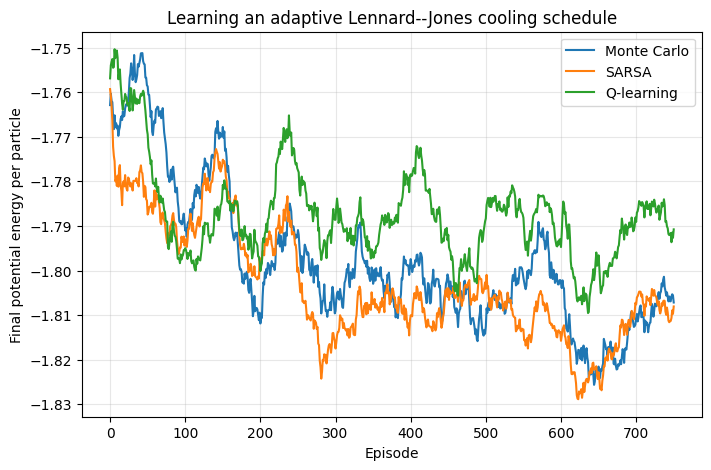

In [15]:
def moving_average(values, window=50):
    values = np.asarray(values)

    if len(values) < window:
        return values

    kernel = np.ones(window) / window

    return np.convolve(
        values,
        kernel,
        mode="valid",
    )


plt.figure(figsize=(8, 5))

plt.plot(
    moving_average(energy_mc),
    label="Monte Carlo",
)

plt.plot(
    moving_average(energy_sarsa),
    label="SARSA",
)

plt.plot(
    moving_average(energy_q),
    label="Q-learning",
)

plt.xlabel("Episode")
plt.ylabel("Final potential energy per particle")
plt.title("Learning an adaptive Lennard--Jones cooling schedule")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

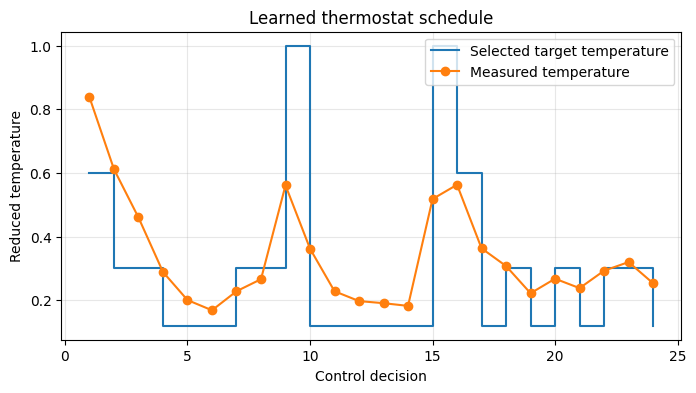

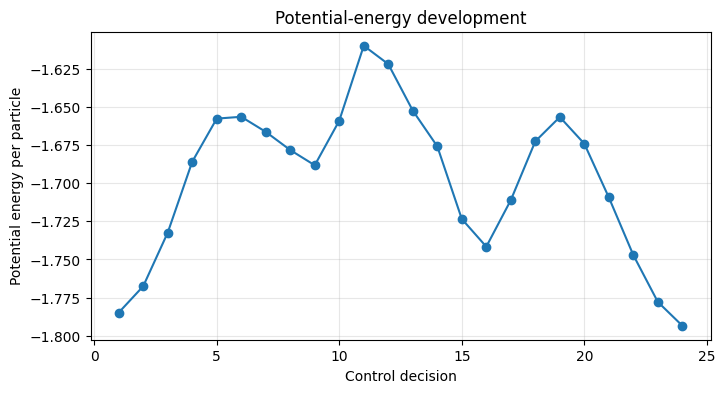

In [16]:
def greedy_rollout(env, Q, seed=3000):
    state = env.reset(seed=seed)
    done = False

    times = []
    temperatures = []
    energies = []
    targets = []

    while not done:
        action = int(np.argmax(Q[state]))

        state, reward, done, info = env.step(
            action
        )

        times.append(env.decision_step)
        temperatures.append(info["temperature"])
        energies.append(
            info["potential_per_particle"]
        )
        targets.append(
            info["target_temperature"]
        )

    return {
        "time": np.asarray(times),
        "temperature": np.asarray(temperatures),
        "energy": np.asarray(energies),
        "target": np.asarray(targets),
    }


rollout = greedy_rollout(
    q_learning_env,
    Q_q,
)

plt.figure(figsize=(8, 4))

plt.step(
    rollout["time"],
    rollout["target"],
    where="post",
    label="Selected target temperature",
)

plt.plot(
    rollout["time"],
    rollout["temperature"],
    marker="o",
    label="Measured temperature",
)

plt.xlabel("Control decision")
plt.ylabel("Reduced temperature")
plt.title("Learned thermostat schedule")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(8, 4))

plt.plot(
    rollout["time"],
    rollout["energy"],
    marker="o",
)

plt.xlabel("Control decision")
plt.ylabel("Potential energy per particle")
plt.title("Potential-energy development")
plt.grid(alpha=0.3)
plt.show()

## Function approximation and deep reinforcement learning

Tabular reinforcement-learning methods store one separate estimate for every state or state-action pair. For example, tabular Q-learning maintains a table

$$
Q(s,a)
$$

and updates one entry after observing a transition

$$
(S_t,A_t,R_{t+1},S_{t+1}).
$$

This representation is practical only when the state and action spaces are sufficiently small. In many applications, the state may instead contain continuous coordinates, sensor measurements, images, molecular configurations, quantum-state features, or robot positions and velocities. The number of possible states may then be extremely large or infinite.

Deep reinforcement learning replaces tables by parametrized functions, usually neural networks. Instead of storing $Q(s,a)$ explicitly, we write

$$
q_\pi(s,a)
\approx
\hat q(s,a;w),
$$

where $w$ denotes the trainable parameters of the network. Similarly, a state-value function may be approximated by

$$
v_\pi(s)
\approx
\hat v(s;w),
$$

and a policy may be represented directly by

$$
\pi_\theta(a\mid s),
$$

where $\theta$ denotes the policy parameters.

The central benefit is **generalization**. Updating the network using experience from one state may also change its predictions in related states. This allows the agent to learn useful structure without visiting every possible state separately.

Deep reinforcement learning is therefore not a different mathematical framework from tabular reinforcement learning. The same objects remain central:

- returns $G_t$;
- value functions $v_\pi$ and $q_\pi$;
- Bellman targets;
- policies $\pi$;
- temporal-difference errors;
- advantages;
- expected return.

The main change is that tables are replaced by trainable functions.


## Value-function approximation

Suppose we want to approximate the action-value function using a neural network

$$
\hat q(s,a;w).
$$

For a sampled transition

$$
(S_t,A_t,R_{t+1},S_{t+1}),
$$

Q-learning suggests the target

$$
Y_t
=
R_{t+1}
+
\gamma
\max_{a'\in A(S_{t+1})}
\hat q(S_{t+1},a';w).
$$

We can then define the squared temporal-difference loss

$$
L_t(w)
=
\left[
Y_t-\hat q(S_t,A_t;w)
\right]^2.
$$

The parameters are updated using gradient descent:

$$
w
\leftarrow
w
-
\alpha
\nabla_w L_t(w).
$$

The gradient is

$$
\nabla_w L_t(w)
=
-2
\left[
Y_t-\hat q(S_t,A_t;w)
\right]
\nabla_w\hat q(S_t,A_t;w).
$$

Thus the network is adjusted so that its current estimate moves toward the sampled Bellman target.

This resembles supervised learning, but there is an important difference. In ordinary supervised learning, the targets are supplied by a fixed dataset. In reinforcement learning, the targets are generated through interaction with the environment and may depend on the network's own current estimates.


## Deep Q-learning

Deep Q-learning replaces the Q-table by a neural network. For a finite action space, the network commonly takes the state $s$ as input and outputs one value for every possible action:

$$
\hat q(s,a_1;w),
\ldots,
\hat q(s,a_m;w).
$$

The greedy action is

$$
a^\star
\in
\arg\max_{a\in A(s)}
\hat q(s,a;w).
$$

Exploration may still be implemented using an $\varepsilon$-greedy behavior policy.

A direct neural-network implementation of Q-learning may be unstable because the target changes while the same network is being trained. Deep Q-learning therefore commonly uses two practical mechanisms.

### Target network

A second set of parameters $w^-$ is used to construct the target:

$$
Y_t
=
R_{t+1}
+
\gamma
\max_{a'}
\hat q(S_{t+1},a';w^-).
$$

The online parameters $w$ are updated frequently, while the target parameters $w^-$ are updated more slowly. This reduces rapid movement of the learning target.

### Experience replay

Transitions are stored in a replay buffer:

$$
\mathcal D
=
\left\{
(S_t,A_t,R_{t+1},S_{t+1})
\right\}.
$$

Training samples are drawn from this buffer rather than always using only the newest transition. This reduces temporal correlations between consecutive observations and allows previous experience to be reused.

The resulting method is called a **deep Q-network**, or DQN.

DQN is naturally suited to discrete action spaces. The learned policy is obtained indirectly from the network:

$$
\pi(s)
\in
\arg\max_a
\hat q(s,a;w).
$$


## Policy parametrization

Value-based methods learn a value function and derive a policy afterward. Policy-based methods represent the policy directly.

For a finite action set

$$
A=\{a_1,\ldots,a_m\},
$$

a neural network may output logits

$$
z_\theta(s,a_1),
\ldots,
z_\theta(s,a_m).
$$

The logits are converted into action probabilities using the softmax function:

$$
\pi_\theta(a_i\mid s)
=
\frac{
\exp(z_\theta(s,a_i))
}{
\sum_{j=1}^{m}
\exp(z_\theta(s,a_j))
}.
$$

This guarantees

$$
\pi_\theta(a_i\mid s)\geq 0
$$

and

$$
\sum_{i=1}^{m}
\pi_\theta(a_i\mid s)=1.
$$

For continuous actions, the network may output parameters of a probability distribution. For example, it may output a mean and variance and define a Gaussian policy.

The optimization objective is

$$
J(\theta)
=
E_{\pi_\theta}[G_0].
$$

Equivalently,

$$
J(\theta)
=
E_{\pi_\theta}
\left[
\sum_{t=0}^{\infty}
\gamma^tR_{t+1}
\right].
$$

The goal is

$$
\theta^\star
\in
\arg\max_\theta J(\theta).
$$

Unlike value-based learning, the policy itself is now the object being optimized.


## Policy-gradient methods

Let a finite trajectory be

$$
\tau
=
(s_0,a_0,r_1,\ldots,s_{T-1},a_{T-1},r_T,s_T).
$$

The objective may be written as

$$
J(\theta)
=
\sum_\tau
P_{\pi_\theta}(\tau)
G_0(\tau).
$$

Differentiating gives

$$
\nabla_\theta J(\theta)
=
\sum_\tau
\nabla_\theta
P_{\pi_\theta}(\tau)
G_0(\tau).
$$

Using the log-derivative identity

$$
\nabla_\theta P_{\pi_\theta}(\tau)
=
P_{\pi_\theta}(\tau)
\nabla_\theta
\log P_{\pi_\theta}(\tau),
$$

we obtain

$$
\nabla_\theta J(\theta)
=
E_{\pi_\theta}
\left[
\nabla_\theta
\log P_{\pi_\theta}(\tau)
G_0
\right].
$$

The trajectory probability contains factors from the initial distribution, the policy, and the environment. Only the policy depends on $\theta$, so

$$
\nabla_\theta
\log P_{\pi_\theta}(\tau)
=
\sum_{t=0}^{T-1}
\nabla_\theta
\log\pi_\theta(A_t\mid S_t).
$$

Therefore,

$$
\nabla_\theta J(\theta)
=
E_{\pi_\theta}
\left[
\sum_{t=0}^{T-1}
\nabla_\theta
\log\pi_\theta(A_t\mid S_t)
G_0
\right].
$$

A more useful form assigns to each action only the return following that action:

$$
\nabla_\theta J(\theta)
=
E_{\pi_\theta}
\left[
\sum_{t=0}^{T-1}
\nabla_\theta
\log\pi_\theta(A_t\mid S_t)
G_t
\right].
$$

This leads to the REINFORCE update

$$
\theta
\leftarrow
\theta
+
\alpha
\sum_{t=0}^{T-1}
\nabla_\theta
\log\pi_\theta(A_t\mid S_t)
G_t.
$$

Actions followed by high return become more probable, while actions followed by low return become less probable.

REINFORCE is conceptually simple and model-free, but its gradient estimates may have high variance because they rely on complete sampled returns.


## Baselines and advantages

A baseline may be subtracted from the return without changing the expected policy gradient:

$$
\nabla_\theta J(\theta)
=
E_{\pi_\theta}
\left[
\nabla_\theta
\log\pi_\theta(A_t\mid S_t)
\left(
G_t-b(S_t)
\right)
\right].
$$

A natural choice is the state-value function:

$$
b(S_t)=v_\pi(S_t).
$$

The difference

$$
A_\pi(s,a)
=
q_\pi(s,a)-v_\pi(s)
$$

is called the advantage function. It measures whether action $a$ is better or worse than the typical action selected from state $s$.

Using an advantage estimate gives the policy-gradient form

$$
\nabla_\theta J(\theta)
=
E_{\pi_\theta}
\left[
\nabla_\theta
\log\pi_\theta(A_t\mid S_t)
A_\pi(S_t,A_t)
\right].
$$

This reduces variance and motivates actor--critic methods.


## Actor--critic methods

Actor--critic methods learn both a policy and a value function.

The **actor** is the policy

$$
\pi_\theta(a\mid s),
$$

and the **critic** is a value approximation such as

$$
\hat v(s;w).
$$

The critic evaluates the actor's current behavior. A simple one-step temporal-difference error is

$$
\delta_t
=
R_{t+1}
+
\gamma
\hat v(S_{t+1};w)
-
\hat v(S_t;w).
$$

This TD error can be interpreted as an estimate of the advantage of the selected action. The actor may therefore be updated by

$$
\theta
\leftarrow
\theta
+
\alpha_\theta
\delta_t
\nabla_\theta
\log\pi_\theta(A_t\mid S_t).
$$

The critic is updated so that its value prediction becomes more accurate, for example using

$$
w
\leftarrow
w
+
\alpha_w
\delta_t
\nabla_w
\hat v(S_t;w).
$$

The critic reduces the variance of the policy update, while the actor allows the policy to be optimized directly.

Actor--critic methods are especially useful when:

- the action space is continuous;
- a stochastic policy is required;
- direct maximization over actions is difficult;
- online TD updates are preferred over complete Monte Carlo returns.


## Proximal policy optimization

Policy-gradient methods may become unstable if one update changes the policy too much. Proximal policy optimization, or PPO, limits the size of the effective policy change.

Let $\pi_{\theta_{\mathrm{old}}}$ be the policy that generated the data. PPO defines the probability ratio

$$
r_t(\theta)
=
\frac{
\pi_\theta(A_t\mid S_t)
}{
\pi_{\theta_{\mathrm{old}}}(A_t\mid S_t)
}.
$$

A ratio larger than one means that the new policy assigns more probability to the sampled action. A ratio smaller than one means that it assigns less.

The clipped PPO objective has the form

$$
L^{\mathrm{clip}}(\theta)
=
E
\left[
\min
\left(
r_t(\theta)\hat A_t,
\operatorname{clip}
\left(
r_t(\theta),
1-\varepsilon,
1+\varepsilon
\right)
\hat A_t
\right)
\right].
$$

The clipping operation limits the benefit of changing the action probability too far from the old policy. PPO therefore retains the policy-gradient idea while making updates more conservative.


## Main families of deep reinforcement learning

| Method | Learned object | Typical target or signal | Policy construction |
|---|---|---|---|
| DQN | $\hat q(s,a;w)$ | Bellman optimality target | Greedy or $\varepsilon$-greedy from $\hat q$ |
| REINFORCE | $\pi_\theta(a\mid s)$ | Complete return $G_t$ | Policy is represented directly |
| Actor--critic | $\pi_\theta(a\mid s)$ and $\hat v(s;w)$ | TD error or advantage | Policy is represented directly |
| PPO | Actor and usually critic | Clipped advantage objective | Policy is represented directly |


## Why deep RL can be difficult

Replacing a table by a neural network introduces generalization, but it also introduces new sources of instability.

### Moving targets

In value-based learning, the target may depend on the same value estimates being trained:

$$
Y_t
=
R_{t+1}
+
\gamma
\max_{a'}
\hat q(S_{t+1},a';w).
$$

As $w$ changes, both the prediction and the target may change.

### Correlated data

Consecutive transitions from one trajectory are usually strongly correlated. Ordinary stochastic-gradient methods work best when training samples are less dependent. Experience replay partially addresses this problem.

### Nonstationary data distribution

The policy changes during learning. Therefore, the distribution of visited states and actions also changes.

### Bootstrapping errors

TD targets use current value estimates. Inaccurate estimates may therefore be propagated to other states.

### Exploration

The agent must collect informative experience while also using what it has already learned. Function approximation does not remove the exploration--exploitation problem.

### Sensitivity to optimization choices

Learning rates, reward scales, network architectures, exploration parameters, target-network updates, and batch sizes can strongly influence training.


## Deep RL in physical applications

In physics-based environments, a neural network may receive states such as:

- coordinates and velocities in molecular dynamics;
- Bloch vectors, amplitudes, or density-matrix features in quantum control;
- positions, velocities, angles, and sensor observations in robotics.

The network may output:

- estimated values for discrete control actions;
- probabilities for discrete actions;
- parameters of a continuous control distribution;
- a value estimate used by a critic.

The environment remains the physical simulator or experiment. The neural network does not replace the equations of motion. It represents the learned value function, policy, or both.


## Central perspective

Deep reinforcement learning may be summarized as

$$
\text{reinforcement learning}
+
\text{function approximation}
+
\text{gradient-based optimization}.
$$

The transition from tabular RL to deep RL does not remove the original reinforcement-learning structure. The agent still generates trajectories, receives rewards, estimates returns or Bellman targets, and improves its behavior.

What changes is the representation:

$$
V(s)
\longrightarrow
\hat v(s;w),
$$

$$
Q(s,a)
\longrightarrow
\hat q(s,a;w),
$$

$$
\pi(a\mid s)
\longrightarrow
\pi_\theta(a\mid s).
$$

The benefit is the ability to generalize across large or continuous state spaces. The cost is that learning becomes less stable and more dependent on optimization choices. Much of modern deep reinforcement learning is therefore concerned with preserving the basic RL objectives while controlling the instability introduced by nonlinear function approximation.